# Garmin Data Exploration & Cleaning

Inspect the raw data pulled from Garmin Connect, identify quality issues, and decide what to clean or keep.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.db import load_dataframe

# Load RAW data (no filters) to see everything
raw = load_dataframe(raw=True)
clean = load_dataframe(raw=False)
print(f"Raw: {len(raw)} activities")
print(f"Clean (after filters): {len(clean)} activities")
print(f"Filtered out: {len(raw) - len(clean)} activities")

Filtered 90 bad records (1251 clean activities)
Raw: 1341 activities
Clean (after filters): 1251 activities
Filtered out: 90 activities


## 1. Schema & Column Overview
What columns do we have, what types, how many nulls?

In [2]:
print("=== Column Types ===")
print(raw.dtypes)
print(f"\n=== Shape: {raw.shape[0]} rows x {raw.shape[1]} columns ===")
print(f"\nDate range: {raw['start_time'].min()} to {raw['start_time'].max()}")

=== Column Types ===
activity_id                int64
name                      object
start_time        datetime64[ns]
distance_m               float64
duration_s               float64
calories                 float64
avg_hr                   float64
max_hr                   float64
avg_speed                float64
elevation_gain           float64
cadence                  float64
distance_km              float64
duration_min             float64
pace_min_km              float64
dtype: object

=== Shape: 1341 rows x 14 columns ===

Date range: 2016-12-10 15:04:15 to 2026-02-07 08:50:48


In [3]:
# Null counts per column
nulls = raw.isnull().sum()
null_pct = (nulls / len(raw) * 100).round(1)
pd.DataFrame({"nulls": nulls, "pct": null_pct}).query("nulls > 0").sort_values("nulls", ascending=False)

,nulls,pct
avg_hr,560,41.8
max_hr,560,41.8
cadence,16,1.2
elevation_gain,15,1.1
pace_min_km,1,0.1


## 2. Basic Statistics
Descriptive stats for all numeric columns — look for suspicious min/max values.

In [4]:
raw[["distance_km", "duration_min", "pace_min_km", "calories",
     "avg_hr", "max_hr", "avg_speed", "elevation_gain", "cadence"]].describe().round(2)

,distance_km,duration_min,pace_min_km,calories,avg_hr,max_hr,avg_speed,elevation_gain,cadence
count,1341.00,1341.00,1340.00,1341.00,781.00,781.00,1341.00,1326.00,1325.00
mean,8.46,40.97,16.52,621.33,149.00,166.68,3.73,31.81,164.68
std,5.60,31.95,134.55,414.26,16.47,15.62,10.00,36.99,26.06
min,0.00,0.00,0.00,0.00,55.00,72.00,0.00,0.00,0.00
25%,3.05,16.21,4.43,233.00,141.00,158.00,3.30,8.00,165.80
50%,9.43,44.55,4.73,653.00,150.00,169.00,3.52,27.00,169.69
75%,11.73,55.58,5.04,861.00,158.00,178.00,3.75,47.00,173.81
max,40.80,512.62,2870.96,3377.00,214.00,215.00,368.39,794.00,197.83


## 3. Outlier Detection
Spot activities with extreme values that may be GPS glitches, indoor treadmill artifacts, or partial recordings.

In [5]:
# Shortest activities (potential fragments)
print("=== Shortest by distance (< 1 km) ===")
short = raw[raw["distance_km"] < 1].sort_values("distance_km")
print(f"{len(short)} activities")
short[["name", "start_time", "distance_km", "duration_min", "pace_min_km"]].head(10)

=== Shortest by distance (< 1 km) ===
87 activities


,name,start_time,distance_km,duration_min,pace_min_km
207,København Løb,2018-02-25 14:41:29,0.00000,22.020101,NaN
1040,Gribskov Løb,2022-06-07 21:35:37,0.00019,0.005517,29.035088
296,Løbebånd,2019-01-22 19:17:08,0.00700,20.096716,2870.959473
295,Løbebånd,2019-01-20 16:38:39,0.00787,20.029083,2544.991556
297,Løbebånd,2019-01-22 19:41:57,0.01617,20.096466,1242.824117
305,Løb,2019-03-03 15:28:15,0.01980,11.292716,570.339238
293,Løbebånd,2018-12-29 18:33:34,0.02043,33.521318,1640.788891
573,Treadmill Running,2020-07-22 13:45:53,0.02140,5.837050,272.759344
298,Løbebånd,2019-01-24 17:43:47,0.02268,30.169883,1330.241747
299,Løbebånd,2019-02-04 14:53:12,0.03006,38.407532,1277.695689


In [6]:
# Extreme paces (too fast or too slow)
print("=== Pace < 2 min/km (impossibly fast) ===")
too_fast = raw[raw["pace_min_km"] < 2]
print(f"{len(too_fast)} activities")
if len(too_fast): display(too_fast[["name", "start_time", "distance_km", "duration_min", "pace_min_km"]].head())

print("\n=== Pace > 15 min/km (walking pace or GPS issues) ===")
too_slow = raw[raw["pace_min_km"] > 15]
print(f"{len(too_slow)} activities")
if len(too_slow): display(too_slow[["name", "start_time", "distance_km", "duration_min", "pace_min_km"]].head())

=== Pace < 2 min/km (impossibly fast) ===
11 activities


,name,start_time,distance_km,duration_min,pace_min_km
141,Tisvilde bær,2017-09-01 12:34:17,12.0,0.000000,0.000000
142,Troldeskoven,2017-09-02 20:08:18,7.0,0.000000,0.000000
156,Frederiksberg C Løb,2017-09-23 14:30:00,10.0,0.452417,0.045242
212,Gribskov,2018-05-20 23:21:00,10.0,0.000000,0.000000
217,Løb,2018-06-09 15:30:00,12.0,0.000000,0.000000



=== Pace > 15 min/km (walking pace or GPS issues) ===
31 activities


,name,start_time,distance_km,duration_min,pace_min_km
13,Frederiksberg C Løb,2016-12-27 01:08:44,3.80254,329.471250,86.645045
208,København Løb,2018-03-04 14:39:25,0.05334,20.640383,386.958808
279,København Løb,2018-11-03 15:38:10,0.75487,71.590747,94.838512
293,Løbebånd,2018-12-29 18:33:34,0.02043,33.521318,1640.788891
294,Løbebånd,2019-01-20 15:59:34,0.04725,30.793599,651.716390


In [7]:
# Heart rate anomalies
print("=== Missing heart rate ===")
no_hr = raw[raw["avg_hr"].isna()]
print(f"{len(no_hr)} activities with no HR data ({len(no_hr)/len(raw)*100:.1f}%)")

print("\n=== Suspicious HR (avg < 80 or max > 220) ===")
weird_hr = raw[(raw["avg_hr"] < 80) | (raw["max_hr"] > 220)].dropna(subset=["avg_hr"])
print(f"{len(weird_hr)} activities")
if len(weird_hr): display(weird_hr[["name", "start_time", "avg_hr", "max_hr", "distance_km", "pace_min_km"]].head())

=== Missing heart rate ===
560 activities with no HR data (41.8%)

=== Suspicious HR (avg < 80 or max > 220) ===
8 activities


,name,start_time,avg_hr,max_hr,distance_km,pace_min_km
13,Frederiksberg C Løb,2016-12-27 01:08:44,55.0,115.0,3.80254,86.645045
374,København Løb,2019-09-10 10:24:29,69.0,102.0,2.63261,5.214198
431,Gribskov Løb,2019-10-19 12:27:22,74.0,101.0,5.76565,4.975042
512,Copenhagen Trail Running,2020-05-04 14:33:38,73.0,95.0,2.56844,5.047428
550,Gribskov Trail Running,2020-06-14 15:41:31,68.0,72.0,4.62932,6.677270


In [8]:
# Cadence anomalies
print("=== Missing cadence ===")
no_cad = raw[raw["cadence"].isna()]
print(f"{len(no_cad)} activities with no cadence data ({len(no_cad)/len(raw)*100:.1f}%)")

print("\n=== Unusual cadence (< 130 or > 210 spm) ===")
weird_cad = raw[(raw["cadence"] < 130) | (raw["cadence"] > 210)].dropna(subset=["cadence"])
print(f"{len(weird_cad)} activities")
if len(weird_cad): display(weird_cad[["name", "start_time", "cadence", "distance_km", "pace_min_km"]].head())

=== Missing cadence ===
16 activities with no cadence data (1.2%)

=== Unusual cadence (< 130 or > 210 spm) ===
62 activities


,name,start_time,cadence,distance_km,pace_min_km
13,Frederiksberg C Løb,2016-12-27 01:08:44,0.062500,3.80254,86.645045
19,København K Løb,2016-12-27 08:51:21,122.734375,0.58769,8.870068
22,Frederiksværk Løb,2016-12-28 15:22:52,126.078125,10.01284,5.018278
36,København K Løb,2017-01-13 14:33:28,124.109375,0.32341,7.267658
44,Frederiksberg C Løb,2017-01-16 15:43:42,102.453125,6.71723,7.571826


## 4. Distributions
Histograms to visually spot where the data clusters and where outliers live.

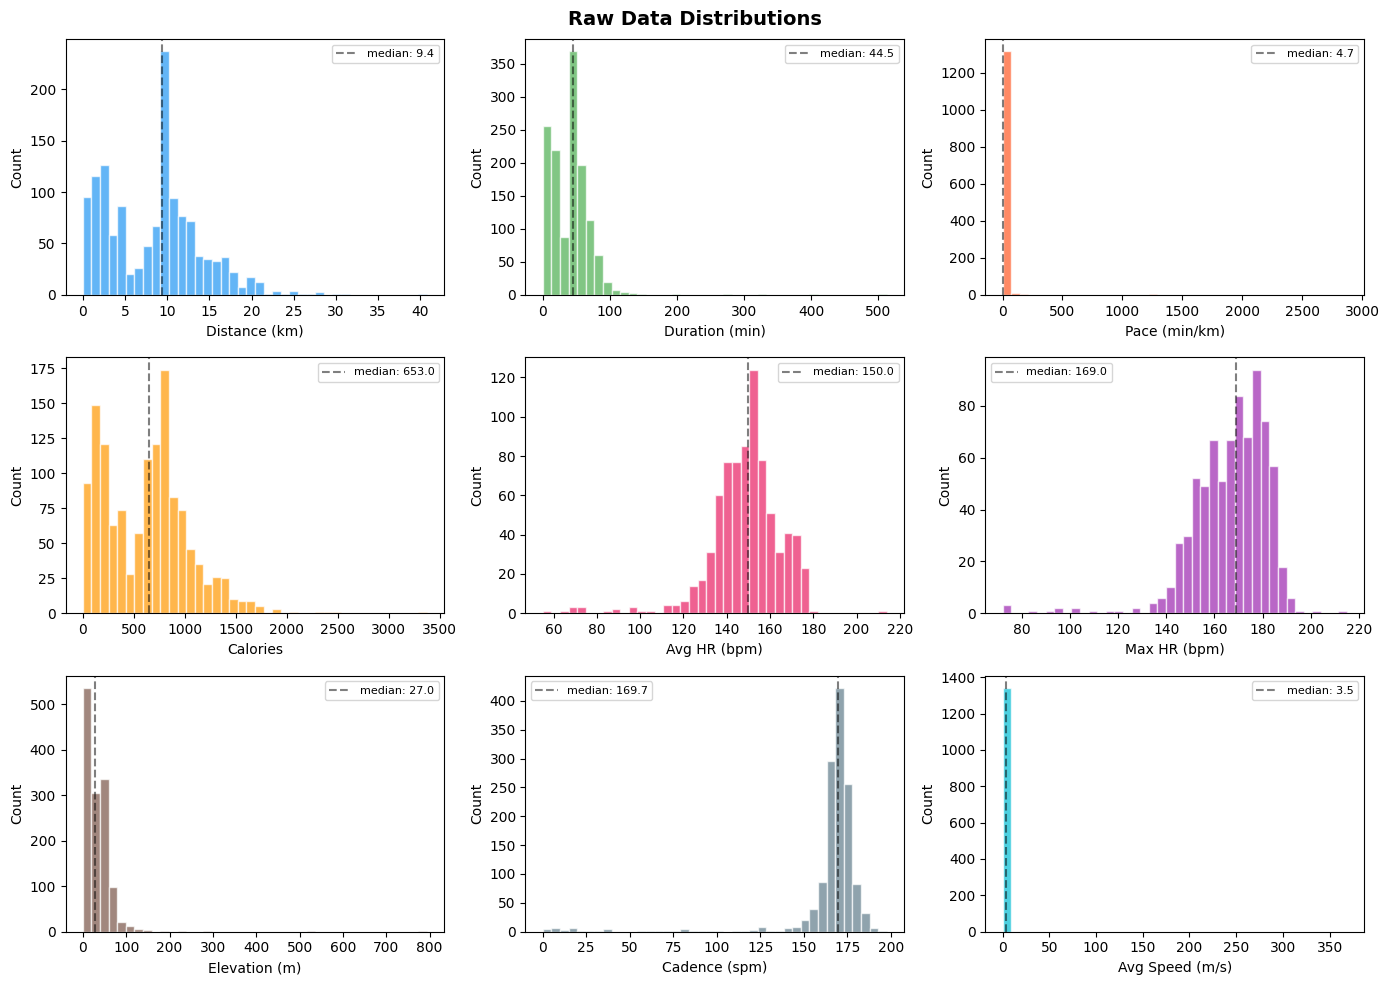

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Raw Data Distributions", fontsize=14, fontweight="bold")

plots = [
    ("distance_km", "Distance (km)", "#2196F3"),
    ("duration_min", "Duration (min)", "#4CAF50"),
    ("pace_min_km", "Pace (min/km)", "#FF5722"),
    ("calories", "Calories", "#FF9800"),
    ("avg_hr", "Avg HR (bpm)", "#E91E63"),
    ("max_hr", "Max HR (bpm)", "#9C27B0"),
    ("elevation_gain", "Elevation (m)", "#795548"),
    ("cadence", "Cadence (spm)", "#607D8B"),
    ("avg_speed", "Avg Speed (m/s)", "#00BCD4"),
]

for ax, (col, label, color) in zip(axes.flat, plots):
    data = raw[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.axvline(data.median(), color="black", linestyle="--", alpha=0.5, label=f"median: {data.median():.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. The Filtered Records
Inspect exactly what the current cleaning filters remove. Are we losing anything valuable?

In [10]:
# What gets filtered out?
filtered_out = raw[~raw["activity_id"].isin(clean["activity_id"])]
print(f"{len(filtered_out)} records removed by current filters:\n")
print("Current filter rules:")
print("  - distance_km >= 0.5")
print("  - duration_s > 0")
print("  - pace between 2-15 min/km")

print(f"\nBreakdown of why they were filtered:")
print(f"  Zero/near-zero distance (< 0.5 km): {len(raw[raw['distance_km'] < 0.5])}")
print(f"  Zero duration: {len(raw[raw['duration_s'] <= 0])}")
print(f"  Pace too fast (< 2 min/km): {len(raw[raw['pace_min_km'] < 2])}")
print(f"  Pace too slow (> 15 min/km): {len(raw[raw['pace_min_km'] > 15])}")

90 records removed by current filters:

Current filter rules:
  - distance_km >= 0.5
  - duration_s > 0
  - pace between 2-15 min/km

Breakdown of why they were filtered:
  Zero/near-zero distance (< 0.5 km): 69
  Zero duration: 10
  Pace too fast (< 2 min/km): 11
  Pace too slow (> 15 min/km): 31


In [11]:
# Show all filtered records for inspection
filtered_out[["name", "start_time", "distance_km", "duration_min",
              "pace_min_km", "avg_hr", "calories"]].sort_values("start_time")

,name,start_time,distance_km,duration_min,pace_min_km,avg_hr,calories
13,Frederiksberg C Løb,2016-12-27 01:08:44,3.802540,329.471250,86.645045,55.0,348.924349
36,København K Løb,2017-01-13 14:33:28,0.323410,2.350433,7.267658,128.0,26.968845
141,Tisvilde bær,2017-09-01 12:34:17,12.000000,0.000000,0.000000,NaN,0.000000
142,Troldeskoven,2017-09-02 20:08:18,7.000000,0.000000,0.000000,NaN,0.000000
150,Tisvildeleje Løb,2017-09-16 14:31:32,0.131680,0.481783,3.658744,141.0,6.000000
...,...,...,...,...,...,...,...
1040,Gribskov Løb,2022-06-07 21:35:37,0.000190,0.005517,29.035088,214.0,0.000000
1066,Tanum Løb terræn,2022-07-29 13:04:04,6.847760,109.142318,15.938398,NaN,360.000000
1237,Tredozio Løb terræn,2023-07-01 14:28:05,3.714470,85.344751,22.976293,NaN,192.000000
1318,Kiruna Løb terræn,2025-07-13 12:13:29,14.496490,278.554720,19.215321,NaN,825.000000


## 6. Activity Names
Check for naming patterns, duplicates, or oddities.

In [12]:
print(f"Unique activity names: {raw['name'].nunique()}")
print(f"\nMost common names:")
raw["name"].value_counts().head(15)

Unique activity names: 57

Most common names:


name
København Løb               350
København Løb terræn        304
Gribskov Løb terræn         151
Gribskov Løb                120
Frederiksberg C Løb          66
Montreal Løb                 51
København K Løb              50
Copenhagen Trail Running     43
Frederiksværk Løb            29
Tisvildeleje Løb             22
Gribskov Trail Running       21
Løbebånd                     16
Løb                          13
København V Løb              10
Halsnæs Løb                   8
Name: count, dtype: int64

## 7. Time Gaps & Frequency
How consistently have you been running? Any long gaps?

In [13]:
clean_sorted = clean.sort_values("start_time").reset_index(drop=True)
gaps = clean_sorted["start_time"].diff().dt.days

print(f"Average days between runs: {gaps.mean():.1f}")
print(f"Median days between runs: {gaps.median():.1f}")
print(f"Longest gap: {gaps.max():.0f} days")

print(f"\n=== Gaps longer than 14 days ===")
long_gaps = gaps[gaps > 14]
for idx in long_gaps.index:
    row = clean_sorted.iloc[idx]
    prev = clean_sorted.iloc[idx - 1]
    print(f"  {int(gaps[idx])}d gap — last run: {prev['start_time'].strftime('%Y-%m-%d')} → next: {row['start_time'].strftime('%Y-%m-%d')}")

Average days between runs: 2.3
Median days between runs: 1.0
Longest gap: 100 days

=== Gaps longer than 14 days ===
  20d gap — last run: 2017-03-19 → next: 2017-04-08
  78d gap — last run: 2017-04-16 → next: 2017-07-04
  17d gap — last run: 2018-01-02 → next: 2018-01-20
  70d gap — last run: 2018-01-20 → next: 2018-04-01
  21d gap — last run: 2018-04-01 → next: 2018-04-22
  27d gap — last run: 2018-04-22 → next: 2018-05-20
  19d gap — last run: 2018-09-04 → next: 2018-09-23
  30d gap — last run: 2018-10-04 → next: 2018-11-04
  100d gap — last run: 2018-12-28 → next: 2019-04-08
  23d gap — last run: 2019-04-18 → next: 2019-05-11
  33d gap — last run: 2019-05-11 → next: 2019-06-13
  25d gap — last run: 2020-03-05 → next: 2020-03-31
  16d gap — last run: 2020-07-15 → next: 2020-07-31
  15d gap — last run: 2020-12-08 → next: 2020-12-24
  16d gap — last run: 2020-12-28 → next: 2021-01-13
  18d gap — last run: 2023-05-25 → next: 2023-06-13
  24d gap — last run: 2023-09-10 → next: 2023-10-0

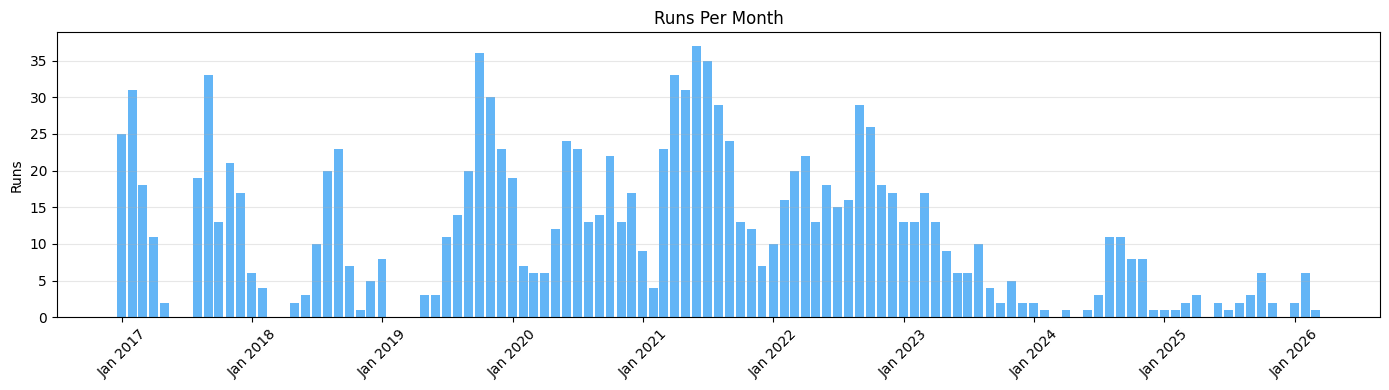

In [14]:
# Runs per month over time
monthly = clean.set_index("start_time").resample("ME").size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly.index, monthly.values, width=25, color="#2196F3", alpha=0.7)
ax.set_ylabel("Runs")
ax.set_title("Runs Per Month")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Year-over-Year Comparison
Quick view of volume by year.

In [15]:
clean["year"] = clean["start_time"].dt.year
yearly = clean.groupby("year").agg(
    runs=("activity_id", "count"),
    total_km=("distance_km", "sum"),
    avg_pace=("pace_min_km", "mean"),
    avg_hr=("avg_hr", "mean"),
    total_elevation=("elevation_gain", "sum"),
    total_calories=("calories", "sum"),
).round(1)
yearly

,runs,total_km,avg_pace,avg_hr,total_elevation,total_calories
year,,,,,,
2016,25,140.1,4.8,154.5,585.0,9460.1
2017,171,1109.0,4.9,152.6,3175.0,79095.2
2018,83,539.7,5.1,151.2,1874.0,39222.0
2019,159,1241.7,4.8,149.7,4606.0,88491.0
2020,166,915.6,4.7,149.3,3135.0,66737.0
2021,258,2571.9,4.7,145.5,9101.0,179875.0
2022,223,2658.6,4.7,149.2,10224.0,195419.0
2023,89,1129.3,4.6,NaN,4973.0,91509.0
2024,46,505.0,4.8,NaN,1849.0,40840.0


## Next Steps

After reviewing the data above, decide:
1. **Adjust filter thresholds?** (currently: distance >= 0.5km, pace 2-15 min/km)
2. **Handle nulls?** (HR and cadence may have gaps from older watches)
3. **Remove specific activities?** (mark individual IDs for exclusion)
4. **Add new derived columns?** (e.g. pace zones, time of day, season)